Number of clusters determined automatically : 4


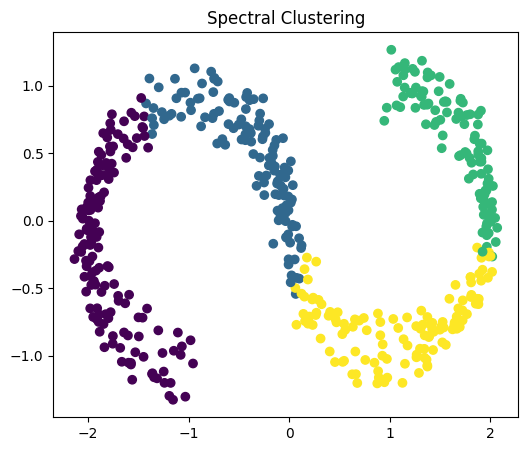

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import numpy as np
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.neighbors import kneighbors_graph
from sklearn.cluster import KMeans
from scipy.linalg import eigh

def adjacency_matrix(X, sigma=1.0, k=5, mode='full'):
  """
Builds the adjacency matrix W from a dataset X.

Parameters:
-----------
X : ndarray (n_samples, n_features)
    Input data.
sigma : float
    Gaussian kernel parameter (kernel width).
k : int
    Number of neighbors for the k-NN graph.
mode : str
    'knn' for k-nearest neighbors, 'full' for complete graph.

Returns:
--------
W : ndarray (n_samples, n_samples)
    Weighted adjacency matrix.
   """

  n = X.shape[0]

  if mode == 'knn':

    # k-nearest neighbors graph (non-symmetric at first)
        A = kneighbors_graph(X, k, mode='connectivity', include_self=False)
        A = np.maximum(A.toarray(), A.toarray().T)  # Make symmetric
  elif mode == 'full':
     # Complete graph (all points connected)
        A = np.ones((n, n)) - np.eye(n)
  else:
        raise ValueError("Mode must be 'knn' or 'full'")

    # Computation of Euclidean distances
  dist = euclidean_distances(X, X)

    # Weights with Gaussian kernel
  W = np.exp(-dist**2 / (2 * sigma**2)) * A

  return W


def degree_matrix_from_W(W, return_vector=False):
  """
Computes the degree matrix D from a similarity matrix W.

Parameters
----------
W : array-like, shape (n, n)
    Similarity matrix (weighted). Must be square.
return_vector : bool, default=False
    If True, also returns the degree vector (shape (n,)).

Returns
-------
D : ndarray, shape (n, n)
    Diagonal degree matrix (D[i,i] = sum_j W[i,j]).
(degrees) : ndarray, shape (n,)
    (optional) degree vector.

"""
  W = np.asarray(W)
  if W.ndim != 2 or W.shape[0] != W.shape[1]:
      raise ValueError("W must be a square matrix (n x n).")

    # sum by row -> degree vector
  degrees = np.sum(W, axis=1)

    # build the diagonal matrix
  D = np.diag(degrees)

  if return_vector:
      return D, degrees
  return D

def laplacian_sym(D,W):#D^(-1/2)LD^(-1/2)
    L=D-W # unnormalized matrix
    if D.ndim == 2:
        d = np.diag(D)
    n = len(d)
    D_inv_sqrt = np.zeros((n, n))

    for i in range(n):
        if d[i] > 0:
            D_inv_sqrt[i, i] = 1 / np.sqrt(d[i])
        else:
            D_inv_sqrt[i, i] = 0.0  # to avoid division by zero
    L_sym = D_inv_sqrt @ L @ D_inv_sqrt
    return L_sym

def extract_k(L_sym,n):
   # Compute all eigenvalues and eigenvectors
    eigvals, eigvecs = eigh(L_sym)
    # 3. Determine k via the largest "gap" between eigenvalues
    # We only consider the first max_clusters eigenvalues
    # max_clusters = min(20, len(eigvals) - 1)
    # gaps = np.diff(eigvals[:max_clusters + 1])
    # k = np.argmax(gaps) + 1

    gaps = np.diff(eigvals[:n+1])
    k = np.argmax(gaps) + 1  # +1 because diff shifts the index by 1
    # 4. Take the corresponding k eigenvectors
    U = eigvecs[:, :k]
    # U is a numpy matrix of size (n, k)
    U_norm = U / np.linalg.norm(U, axis=1, keepdims=True)
    return U,k,U_norm

def distance(u,v):
    v=np.array(u)-np.array(v)
    r=np.sum(v*v)
    return np.sqrt(r)


def spectral_clustering(X, sigma=0.5, k_neighbors=5, mode='full', k_clusters=None, tol=1e-6):
    """
      Performs spectral partitioning on the data X.
      labels : ndarray (n_samples,)
      Cluster labels assigned to each point.
    """
    # 1. Build the adjacency matrix
    W = adjacency_matrix(X, sigma=sigma, k=k_neighbors, mode=mode)
    n = W.shape[0]

    # 2. Compute the degree matrix
    D, degrees = degree_matrix_from_W(W, return_vector=True)

    # 3. Compute the symmetric normalized Laplacian matrix
    L_sym = laplacian_sym(D, W)

    # 4. Extract the eigenvectors
    # If k_clusters is not specified, extract_k will try to determine it.
    if k_clusters is None:
        U, k_actual, U_norm = extract_k(L_sym, n)
        print(f"Number of clusters determined automatically : {k_actual}")
        k_to_use = k_actual
    else:
        # If k_clusters is specified, we take the first k_clusters eigenvectors
        eigvals, eigvecs = eigh(L_sym)
        U = eigvecs[:, :k_clusters]
        U_norm = U / np.linalg.norm(U, axis=1, keepdims=True)
        k_to_use = k_clusters
        print(f"Use of specified k_clusters: {k_to_use}")


    kmeans = KMeans(
    n_clusters=k_to_use,
    tol=tol,
    n_init=10,
    random_state=0
    )

    labels = kmeans.fit_predict(U_norm)

    return labels

def visualize_clustering(X, labels):
    plt.figure(figsize=(6,5))
    plt.scatter(X[:, 0], X[:, 1], c=labels)
    plt.title("Spectral Clustering")
    plt.show()

from sklearn.datasets import make_s_curve
X, y = make_s_curve(
  n_samples=500,
  noise=0.05,
 random_state=10
)
labels= spectral_clustering(X)
from sklearn.decomposition import PCA
X_2d = PCA(n_components=2).fit_transform(X)
visualize_clustering(X_2d, labels)
